In [1]:
import os, sys, random, time, warnings, platform, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from tqdm.auto import tqdm

import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             accuracy_score)

%matplotlib inline
sns.set_style("whitegrid")

# Single-point random-seed control for everything that could vary
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Log versions — these go into the reproducibility paragraph of the report
print(f"python       : {platform.python_version()}")
print(f"torch        : {torch.__version__}")
import sklearn, transformers, sentence_transformers
print(f"transformers : {transformers.__version__}")
print(f"sentence_tr. : {sentence_transformers.__version__}")
print(f"sklearn      : {sklearn.__version__}")
print(f"device       : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    

python       : 3.11.14
torch        : 2.12.0+cu130
transformers : 5.9.0
sentence_tr. : 5.5.1
sklearn      : 1.9.0
device       : cpu


In [2]:
import subprocess
print(subprocess.run(["find", "/home", "-name", "analysis-of-corporate-reports-dataset", "-type", "d"],
                     capture_output=True, text=True).stdout)

/home/renku/work/analysis-of-corporate-reports-dataset



In [3]:
import glob, json, os

folder = "/home/renku/work/analysis-of-corporate-reports-dataset"

data = {}
errors = []

for path in glob.glob(os.path.join(folder, "**", "*.json"), recursive=True):
    try:
        with open(path, "r", encoding="utf-8") as f:
            data[os.path.basename(path)] = json.load(f)
    except Exception as e:
        errors.append((path, str(e)))

print(f"Loaded {len(data)} files")
if errors:
    print(f"{len(errors)} failed:")
    for p, e in errors:
        print(" ", p, "->", e)

Loaded 992 files


In [4]:
sample = list(data.values())[0]
print(type(sample))
print(json.dumps(sample, indent=2)[:2000])   # first chunk of one file

<class 'dict'>
{
  "cik": "1001039",
  "company": "WALT DISNEY CO/",
  "filing_type": "10-K",
  "filing_date": "2016-11-23",
  "period_of_report": "2016-10-01",
  "sic": "4841",
  "state_of_inc": "DE",
  "state_location": "CA",
  "fiscal_year_end": "1001",
  "filing_html_index": "https://www.sec.gov/Archives/edgar/data/1001039/0001001039-16-000516-index.html",
  "htm_filing_link": "https://www.sec.gov/Archives/edgar/data/1001039/000100103916000516/fy2016_q4x10k.htm",
  "complete_text_filing_link": "https://www.sec.gov/Archives/edgar/data/1001039/0001001039-16-000516.txt",
  "filename": "1001039_10K_2016_0001001039-16-000516.htm",
  "item_1": "ITEM 1. Business\nThe Walt Disney Company, together with its subsidiaries, is a diversified worldwide entertainment company with operations in four business segments: Media Networks, Parks and Resorts, Studio Entertainment, and Consumer Products & Interactive Media. For convenience, the terms \u201cCompany\u201d and \u201cwe\u201d are used to refe

In [5]:
df = pd.DataFrame(list(data.values()))
print(df.shape)        # (number of filings, number of columns)
df.head()

(992, 36)


,cik,company,filing_type,filing_date,period_of_report,sic,state_of_inc,state_location,fiscal_year_end,filing_html_index,...,item_9A,item_9B,item_9C,item_10,item_11,item_12,item_13,item_14,item_15,item_16
0,1001039,WALT DISNEY CO/,10-K,2016-11-23,2016-10-01,4841,DE,CA,1001,https://www.sec.gov/Archives/edgar/data/100103...,...,ITEM 9A. Controls and Procedures\nEvaluation o...,ITEM 9B. Other Information\nNone.\nPART III,,"ITEM 10. Directors, Executive Officers and Cor...",ITEM 11. Executive Compensation\nInformation a...,ITEM 12. Security Ownership of Certain Benefic...,ITEM 13. Certain Relationships and Related Tra...,ITEM 14. Principal Accounting Fees and Service...,ITEM 15. Exhibits and Financial Statement Sche...,
1,1001039,WALT DISNEY CO/,10-K,2017-11-22,2017-09-30,4841,DE,CA,0930,https://www.sec.gov/Archives/edgar/data/100103...,...,ITEM 9A. Controls and Procedures\nEvaluation o...,ITEM 9B. Other Information\nNone.\nPART III,,"ITEM 10. Directors, Executive Officers and Cor...",ITEM 11. Executive Compensation\nInformation a...,ITEM 12. Security Ownership of Certain Benefic...,ITEM 13. Certain Relationships and Related Tra...,ITEM 14. Principal Accounting Fees and Service...,ITEM 15. Exhibits and Financial Statement Sche...,
2,1001039,WALT DISNEY CO/,10-K,2018-11-21,2018-09-29,4841,DE,CA,0929,https://www.sec.gov/Archives/edgar/data/100103...,...,ITEM 9A. Controls and Procedures\nEvaluation o...,ITEM 9B. Other Information\nNone.\nPART III,,"ITEM 10. Directors, Executive Officers and Cor...",ITEM 11. Executive Compensation\nInformation a...,ITEM 12. Security Ownership of Certain Benefic...,ITEM 13. Certain Relationships and Related Tra...,ITEM 14. Principal Accounting Fees and Service...,ITEM 15. Exhibits and Financial Statement Sche...,
3,100885,UNION PACIFIC CORP,10-K,2017-02-03,2016-12-31,4011,UT,NE,1119,https://www.sec.gov/Archives/edgar/data/100885...,...,Item 9A. Controls and Procedures\n﻿\nAs of the...,Item 9B. Other Information\n﻿\nNone.\n﻿\nPART ...,,"Item 10. Directors, Executive Officers, and Co...",Item 11. Executive Compensation\n﻿\nInformatio...,Item 12. Security Ownership of Certain Benefic...,Item 13. Certain Relationships and Related Tra...,Item 14. Principal Accountant Fees and Service...,"Item 15. Exhibits, Financial Statement Schedul...",
4,100885,UNION PACIFIC CORP,10-K,2018-02-09,2017-12-31,4011,UT,NE,1231,https://www.sec.gov/Archives/edgar/data/100885...,...,Item 9A. Controls and Procedures\n﻿\nAs of the...,Item 9B. Other Information\n﻿\nNone.\n﻿\nPART ...,,"Item 10. Directors, Executive Officers, and Co...",Item 11. Executive Compensation\n﻿\nInformatio...,Item 12. Security Ownership of Certain Benefic...,Item 13. Certain Relationships and Related Tra...,Item 14. Principal Accountant Fees and Service...,"Item 15. Exhibits, Financial Statement Schedul...",


In [12]:
df = df.drop(columns=["filing_type","filing_html_index", "htm_filing_link","complete_text_filing_link"])

,cik,company,filing_date,report_date,sic,incorporation_state,state_location,fiscal_year_end,filename,BUSINESS GENERAL DEVELOPMENT OF BUSINESS,...,item_9C,item_10,item_11,item_12,item_13,item_14,item_15,item_16,sector,company_clean
0,1001039,WALT DISNEY CO/,2016-11-23,2016-10-01,4841,DE,CA,1001,1001039_10K_2016_0001001039-16-000516.htm,"ITEM 1. Business\nThe Walt Disney Company, tog...",...,,"ITEM 10. Directors, Executive Officers and Cor...",ITEM 11. Executive Compensation\nInformation a...,ITEM 12. Security Ownership of Certain Benefic...,ITEM 13. Certain Relationships and Related Tra...,ITEM 14. Principal Accounting Fees and Service...,ITEM 15. Exhibits and Financial Statement Sche...,,Communication Services,Walt Disney Co.
1,1001039,WALT DISNEY CO/,2017-11-22,2017-09-30,4841,DE,CA,0930,1001039_10K_2017_0001001039-17-000198.htm,"ITEM 1. Business\nThe Walt Disney Company, tog...",...,,"ITEM 10. Directors, Executive Officers and Cor...",ITEM 11. Executive Compensation\nInformation a...,ITEM 12. Security Ownership of Certain Benefic...,ITEM 13. Certain Relationships and Related Tra...,ITEM 14. Principal Accounting Fees and Service...,ITEM 15. Exhibits and Financial Statement Sche...,,Communication Services,Walt Disney Co.
2,1001039,WALT DISNEY CO/,2018-11-21,2018-09-29,4841,DE,CA,0929,1001039_10K_2018_0001001039-18-000187.htm,"ITEM 1. Business\nThe Walt Disney Company, tog...",...,,"ITEM 10. Directors, Executive Officers and Cor...",ITEM 11. Executive Compensation\nInformation a...,ITEM 12. Security Ownership of Certain Benefic...,ITEM 13. Certain Relationships and Related Tra...,ITEM 14. Principal Accounting Fees and Service...,ITEM 15. Exhibits and Financial Statement Sche...,,Communication Services,Walt Disney Co.
3,100885,UNION PACIFIC CORP,2017-02-03,2016-12-31,4011,UT,NE,1119,100885_10K_2016_0000100885-17-000056.htm,Item 1. Business\n﻿\nGENERAL\n﻿\nUnion Pacific...,...,,"Item 10. Directors, Executive Officers, and Co...",Item 11. Executive Compensation\n﻿\nInformatio...,Item 12. Security Ownership of Certain Benefic...,Item 13. Certain Relationships and Related Tra...,Item 14. Principal Accountant Fees and Service...,"Item 15. Exhibits, Financial Statement Schedul...",,Industrials,Union Pacific Corp
4,100885,UNION PACIFIC CORP,2018-02-09,2017-12-31,4011,UT,NE,1231,100885_10K_2017_0000100885-18-000048.htm,Item 1. Business\n﻿\nGENERAL\n﻿\nUnion Pacific...,...,,"Item 10. Directors, Executive Officers, and Co...",Item 11. Executive Compensation\n﻿\nInformatio...,Item 12. Security Ownership of Certain Benefic...,Item 13. Certain Relationships and Related Tra...,Item 14. Principal Accountant Fees and Service...,"Item 15. Exhibits, Financial Statement Schedul...",,Industrials,Union Pacific Corp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,1053507,AMERICAN TOWER CORP /MA/,2019-02-27,2018-12-31,6798,DE,MA,1231,1053507_10K_2018_0001053507-19-000012.htm,ITEM 1. BUSINESS\nOverview\nWe are one of the ...,...,,"ITEM 10.\nDIRECTORS, EXECUTIVE OFFICERS AND CO...",ITEM 11.\nEXECUTIVE COMPENSATION\nThe informat...,ITEM 12.\nSECURITY OWNERSHIP OF CERTAIN BENEFI...,ITEM 13.\nCERTAIN RELATIONSHIPS AND RELATED TR...,ITEM 14.\nPRINCIPAL ACCOUNTING FEES AND SERVIC...,"ITEM 15.\nEXHIBITS, FINANCIAL STATEMENT SCHEDU...",ITEM 16.\nFORM 10-K SUMMARY\nNone.,Real Estate,American Tower Corp
76,1053507,AMERICAN TOWER CORP /MA/,2020-02-25,2019-12-31,6798,DE,MA,1231,1053507_10K_2019_0001053507-20-000028.htm,ITEM 1.\nBUSINESS\nOverview\nWe are one of the...,...,,"ITEM 10.\nDIRECTORS, EXECUTIVE OFFICERS AND CO...",ITEM 11.\nEXECUTIVE COMPENSATION\nThe informat...,ITEM 12.\nSECURITY OWNERSHIP OF CERTAIN BENEFI...,ITEM 13.\nCERTAIN RELATIONSHIPS AND RELATED TR...,ITEM 14.\nPRINCIPAL ACCOUNTING FEES AND SERVIC...,"ITEM 15.\nEXHIBITS, FINANCIAL STATEMENT SCHEDU...",ITEM 16.\nFORM 10-K SUMMARY\nNone.,Real Estate,American Tower Corp
77,1053507,AMERICAN TOWER CORP /MA/,2021-02-25,2020-12-31,6798,DE,MA,1231,1053507_10K_

In [16]:
# df = df.rename(columns={"period_of_report": "report_date",
#                         "state_of_inc": "incorporation_state",
#                         "item_1":"BUSINESS GENERAL DEVELOPMENT OF BUSINESS",
#                         "item_1B":"UNRESOLVED STAFF COMMENTS",
#                         "item_1C":"Cybersecurity",
#                         "item_2":"PROPERTIES",
#                         "item_3":"LEGAL PROCEEDINGS",
#                         "item_4":"MINE SAFETY DISCLOSURES",
#                         "item_5":"MARKET FOR REGISTRANT’S COMMON EQUITY, RELATED STOCKHOLDER MATTERS AND ISSUER PURCHASES OF EQUITY SECURITIES",
#                         "item_6":"SELECTED FINANCIAL DATA",
#                         "item_7":"Management's Discussion and Analysis of Financial Condition and Results of Operations",
#                         "item_7A":"QUANTITATIVE AND QUALITATIVE DISCLOSURES ABOUT MARKET RISK",
#                         "item_8":"FINANCIAL STATEMENTS AND SUPPLEMENTARY DATA",
#                         "item_9B":"OTHER INFORMATION",
#                          "item_9C":"DISCLOSURE REGARDING FOREIGN JURISDICTIONS THAT PREVENT INSPECTIONS ",
#                         "item_10":"DIRECTORS, EXECUTIVE OFFICERS AND CORPORATE GOVERNANCE",
#                         "item_11":"EXECUTIVE COMPENSATION",
#                         "item_12":"SECURITY OWNERSHIP OF CERTAIN BENEFICIAL OWNERS AND MANAGEMENT AND RELATED STOCKHOLDER MATTERS",
#                         "item_13":"CERTAIN RELATIONSHIPS AND RELATED TRANSACTIONS, AND DIRECTOR INDEPENDENCE ",
#                         "item_14":"PRINCIPAL ACCOUNTING FEES AND SERVICES",
#                         "item_15":"EXHIBITS, FINANCIAL STATEMENT SCHEDULES",
#                         "item_16":"FORM 10-K SUMMARY"                    
#                        })

In [19]:
# SIC code → broad sector
SIC_TO_SECTOR = {
    "2000": "Consumer Staples",
    "2080": "Consumer Staples",
    "2111": "Consumer Staples",
    "2810": "Materials",
    "2834": "Healthcare",
    "2836": "Healthcare",
    "2840": "Consumer Staples",
    "2844": "Consumer Staples",
    "2911": "Energy",
    "3021": "Consumer Discretionary",
    "3523": "Industrials",
    "3531": "Industrials",
    "3570": "Technology",
    "3571": "Technology",
    "3576": "Technology",
    "3600": "Industrials",
    "3663": "Technology",
    "3674": "Technology",
    "3711": "Consumer Discretionary",
    "3714": "Manufacture motor vehicle parts and accessories",
    "3721": "Industrials",
    "3724": "Industrials",
    "3730": "Industrials",
    "3760": "Industrials",
    "3823": "Healthcare",
    "3829": "Healthcare",
    "3841": "Healthcare",
    "3842": "Healthcare",
    "3845": "Healthcare",
    "4011": "Industrials",
    "4210": "Industrials",
    "4513": "Industrials",
    "4700": "Transportation service",
    "4812": "Communication Services",
    "4813": "Communication Services",
    "4841": "Communication Services",
    "4911": "Utilities",
    "4931": "Utilities",
    "5211": "Consumer Discretionary",
    "5331": "Consumer Discretionary",
    "5810": "Consumer Discretionary",
    "5812": "Consumer Discretionary",
    "5912": "Healthcare",
    "5961": "Consumer Discretionary",
    "6021": "Financials",
    "6022": "Financials",
    "6199": "Financials",
    "6211": "Financials",
    "6311": "Financials",
    "6324": "Healthcare",
    "6331": "Financials",
    "6798": "Real Estate",
    "7370": "Technology",
    "7372": "Technology",
    "7389": "Financials",
    "7841": "Communication Services",
    "7990": "Communication Services",
}

# Duplicate CIKs to skip (older/renamed entities)
EXCLUDE_CIKS = {
    "1649338",  # Broadcom Ltd → superseded by Broadcom Inc.
    "884905",   # Praxair → merged into Linde
    "101829",   # United Technologies → merged/rebranded
    "1744489",  # Walt Disney Co duplicate CIK
}

NAME_OVERRIDES = {
    "AT&T INC.": "AT&T Inc.",
    "QUALCOMM INC/DE": "Qualcomm Inc.",
    "AMAZON COM INC": "Amazon.com Inc.",
    "JPMORGAN CHASE & CO": "JPMorgan Chase & Co.",
    "BANK OF AMERICA CORP /DE/": "Bank of America Corp",
    "WELLS FARGO & COMPANY/MN": "Wells Fargo & Company",
    "US BANCORP \\DE\\": "U.S. Bancorp",
    "COSTCO WHOLESALE CORP /NEW": "Costco Wholesale Corp",
    "SALESFORCE.COM, INC.": "Salesforce Inc.",
    "LOWES COMPANIES INC": "Lowe's Companies Inc.",
    "PRICELINE GROUP INC.": "Booking Holdings (Priceline)",
    "SCHWAB CHARLES CORP": "Charles Schwab Corp",
    "MCDONALDS CORP": "McDonald's Corp",
    "ABBVIE INC.": "AbbVie Inc.",
    "SERVICENOW, INC.": "ServiceNow Inc.",
    "ADOBE INC.": "Adobe Inc.",
    "INTEL CORP": "Intel Corp",
    "NVIDIA CORP": "NVIDIA Corp",
    "3M CO": "3M Co.",
    "MICROSOFT CORP": "Microsoft Corp",
    "ORACLE CORP": "Oracle Corp",
    "INTUIT INC": "Intuit Inc.",
    "COMCAST CORP": "Comcast Corp",
    "FEDEX CORP": "FedEx Corp",
    "CVS HEALTH CORP": "CVS Health Corp",
    "ELI LILLY & CO": "Eli Lilly & Co.",
    "MERCK & CO., INC.": "Merck & Co. Inc.",
    "AMGEN INC": "Amgen Inc.",
    "LINDE PLC": "Linde plc",
    "MEDTRONIC PLC": "Medtronic plc",
    "ACCENTURE PLC": "Accenture plc",
    "T-MOBILE US, INC.": "T-Mobile US Inc.",
    "META PLATFORMS, INC.": "Meta Platforms Inc.",
    "ALPHABET INC.": "Alphabet Inc.",
    "TESLA, INC.": "Tesla Inc.",
    "NIKE, INC.": "Nike Inc.",
    "PAYPAL HOLDINGS, INC.": "PayPal Holdings Inc.",
    "SIMON PROPERTY GROUP INC.": "Simon Property Group Inc.",
    "AMERICAN TOWER CORP /MA/": "American Tower Corp",
    "UNITEDHEALTH GROUP INC": "UnitedHealth Group Inc.",
    "NEXTERA ENERGY INC": "NextEra Energy Inc.",
    "PALANTIR TECHNOLOGIES INC.": "Palantir Technologies Inc.",
    "BLACKROCK INC.": "BlackRock Inc.",
    "BLACKROCK, INC.": "BlackRock Inc.",
    "UBER TECHNOLOGIES, INC": "Uber Technologies Inc.",
    "MASTERCARD INC": "Mastercard Inc.",
    "GOLDMAN SACHS GROUP INC": "Goldman Sachs Group Inc.",
    "MORGAN STANLEY": "Morgan Stanley",
    "AMERICAN EXPRESS CO": "American Express Co.",
    "METLIFE INC": "MetLife Inc.",
    "CITIGROUP INC": "Citigroup Inc.",
    "CISCO SYSTEMS, INC.": "Cisco Systems Inc.",
    "ADVANCED MICRO DEVICES INC": "Advanced Micro Devices Inc.",
    "TEXAS INSTRUMENTS INC": "Texas Instruments Inc.",
    "BROADCOM INC.": "Broadcom Inc.",
    "VISA INC.": "Visa Inc.",
    "CAPITAL ONE FINANCIAL CORP": "Capital One Financial Corp",
    "BANK OF NEW YORK MELLON CORP": "Bank of New York Mellon Corp",
    "STARBUCKS CORP": "Starbucks Corp",
    "TARGET CORP": "Target Corp",
    "WALMART INC.": "Walmart Inc.",
    "HOME DEPOT INC": "Home Depot Inc.",
    "COLGATE PALMOLIVE CO": "Colgate-Palmolive Co.",
    "PROCTER & GAMBLE CO": "Procter & Gamble Co.",
    "COCA COLA CO": "Coca-Cola Co.",
    "PEPSICO INC": "PepsiCo Inc.",
    "EXXON MOBIL CORP": "ExxonMobil Corp",
    "CHEVRON CORP": "Chevron Corp",
    "CONOCOPHILLIPS": "ConocoPhillips",
    "BOEING CO": "Boeing Co.",
    "GENERAL DYNAMICS CORP": "General Dynamics Corp",
    "LOCKHEED MARTIN CORP": "Lockheed Martin Corp",
    "HONEYWELL INTERNATIONAL INC": "Honeywell International Inc.",
    "GENERAL ELECTRIC CO": "General Electric Co.",
    "EMERSON ELECTRIC CO": "Emerson Electric Co.",
    "CATERPILLAR INC": "Caterpillar Inc.",
    "DEERE & CO": "Deere & Co.",
    "UNION PACIFIC CORP": "Union Pacific Corp",
    "UNITED PARCEL SERVICE INC": "United Parcel Service Inc.",
    "VERIZON COMMUNICATIONS INC": "Verizon Communications Inc.",
    "WALT DISNEY CO/": "Walt Disney Co.",
    "NETFLIX INC": "Netflix Inc.",
    "SOUTHERN CO": "Southern Co.",
    "DUKE ENERGY CORP": "Duke Energy Corp",
    "GENERAL MOTORS CO": "General Motors Co.",
    "DANAHER CORP /DE/": "Danaher Corp",
    "THERMO FISHER SCIENTIFIC INC.": "Thermo Fisher Scientific Inc.",
    "INTUITIVE SURGICAL INC": "Intuitive Surgical Inc.",
    "JOHNSON & JOHNSON": "Johnson & Johnson",
    "BRISTOL MYERS SQUIBB CO": "Bristol Myers Squibb Co.",
    "ABBOTT LABORATORIES": "Abbott Laboratories",
    "PFIZER INC": "Pfizer Inc.",
    "GILEAD SCIENCES, INC.": "Gilead Sciences Inc.",
    "ALTRIA GROUP, INC.": "Altria Group Inc.",
    "PHILIP MORRIS INTERNATIONAL INC.": "Philip Morris International Inc.",
    "MONDELEZ INTERNATIONAL, INC.": "Mondelez International Inc.",
    "AMERICAN INTERNATIONAL GROUP INC": "American International Group Inc.",
    "BERKSHIRE HATHAWAY INC": "Berkshire Hathaway Inc.",
    "INTERNATIONAL BUSINESS MACHINES CORP": "IBM Corp",
    "APPLE INC.": "Apple Inc.",
}

In [18]:
# 1. Drop the superseded/duplicate entities
df = df[~df["cik"].isin(EXCLUDE_CIKS)].copy()

# 2. Map SIC code → broad sector (unmapped codes become NaN)
df["sector"] = df["sic"].map(SIC_TO_SECTOR)

# 3. Clean company names. .replace() swaps exact matches and
#    leaves everything else untouched (unlike .map, which would
#    turn non-matches into NaN)
df["company_clean"] = df["company"].replace(NAME_OVERRIDES)

In [21]:
# SIC codes present in the data but missing from your sector map
missing_sic = df.loc[df["sector"].isna(), "sic"].unique()
print("SIC codes with no sector:", missing_sic)

# Company names that did NOT get cleaned (still in raw ALL-CAPS form)
not_overridden = sorted(set(df["company"]) - set(NAME_OVERRIDES.keys()))
print(f"{len(not_overridden)} company names not in NAME_OVERRIDES:")
for name in not_overridden:
    print("  ", name)

SIC codes with no sector: <StringArray>
['4700', '3714']
Length: 2, dtype: str
42 company names not in NAME_OVERRIDES:
   ADOBE SYSTEMS INC
   AMERICAN INTERNATIONAL GROUP, INC.
   APPLE INC
   AbbVie Inc.
   Accenture plc
   Alphabet Inc.
   Apple Inc.
   Bank of New York Mellon Corp
   BlackRock Inc.
   BlackRock, Inc.
   Booking Holdings Inc.
   Broadcom Inc.
   CVS HEALTH Corp
   Duke Energy CORP
   ELI LILLY & Co
   Facebook Inc
   GILEAD SCIENCES INC
   General Motors Co
   HOME DEPOT, INC.
   INTUIT INC.
   LILLY ELI & CO
   Mastercard Inc
   Medtronic plc
   Merck & Co., Inc.
   Meta Platforms, Inc.
   Mondelez International, Inc.
   NIKE INC
   NIKE, Inc.
   PROCTER & GAMBLE Co
   Palantir Technologies Inc.
   PayPal Holdings, Inc.
   Philip Morris International Inc.
   Priceline Group Inc.
   SALESFORCE COM INC
   SIMON PROPERTY GROUP INC /DE/
   Salesforce, Inc.
   ServiceNow, Inc.
   T-Mobile US, Inc.
   Tesla, Inc.
   Uber Technologies, Inc
   WAL MART STORES INC
   Walmar

In [23]:
df.groupby("sector")["company_clean"].nunique().sort_values(ascending=False)

sector
Financials                24
Technology                24
Healthcare                18
Consumer Discretionary    14
Industrials               11
Consumer Staples           7
Communication Services     6
Energy                     3
Real Estate                3
Utilities                  3
Materials                  1
Name: company_clean, dtype: int64

In [24]:
companies_by_sector = (
    df.groupby("sector")["company_clean"]
      .unique()                 # unique names per sector
      .apply(sorted)            # alphabetise within each sector
)

for sector, companies in companies_by_sector.items():
    print(f"\n{sector} ({len(companies)} companies)")
    for c in companies:
        print("  ", c)


Communication Services (6 companies)
   AT&T Inc.
   Comcast Corp
   Netflix Inc.
   T-Mobile US, Inc.
   Verizon Communications Inc.
   Walt Disney Co.

Consumer Discretionary (14 companies)
   Amazon.com Inc.
   Costco Wholesale Corp
   General Motors Co
   HOME DEPOT, INC.
   Home Depot Inc.
   Lowe's Companies Inc.
   McDonald's Corp
   NIKE INC
   NIKE, Inc.
   Starbucks Corp
   Target Corp
   Tesla, Inc.
   WAL MART STORES INC
   Walmart Inc.

Consumer Staples (7 companies)
   Altria Group Inc.
   Coca-Cola Co.
   Colgate-Palmolive Co.
   Mondelez International, Inc.
   PROCTER & GAMBLE Co
   PepsiCo Inc.
   Philip Morris International Inc.

Energy (3 companies)
   Chevron Corp
   ConocoPhillips
   ExxonMobil Corp

Financials (24 companies)
   AMERICAN INTERNATIONAL GROUP, INC.
   Accenture plc
   American Express Co.
   American International Group Inc.
   Bank of America Corp
   Bank of New York Mellon Corp
   Berkshire Hathaway Inc.
   BlackRock Inc.
   BlackRock, Inc.
   Boo

In [105]:
# df["company"] = df["company_clean"]
# df = df.drop(columns=["company_clean"])
# df

In [102]:
df.to_csv("esg_reports.csv", index=False)

In [38]:
sample = list(data.values())[0]
item_keys = [k for k in sample if k.startswith("item_")]
print(item_keys)

['item_1', 'item_1A', 'item_1B', 'item_1C', 'item_2', 'item_3', 'item_4', 'item_5', 'item_6', 'item_7', 'item_7A', 'item_8', 'item_9', 'item_9A', 'item_9B', 'item_9C', 'item_10', 'item_11', 'item_12', 'item_13', 'item_14', 'item_15', 'item_16']


In [39]:
ESG_ITEMS = ["item_1", "item_1A", "item_7"]   

def get_text(doc):
    return "\n\n".join(doc.get(k, "") for k in ESG_ITEMS if doc.get(k))

In [106]:
import re

ESG_SEED = {
    "environment","emissions","carbon","climate","greenhouse","renewable",
    "pollution","waste","water","energy","sustainability","biodiversity",
    "diversity","inclusion","employee","safety","health","human rights",
    "community","labor","training","workforce","gender",
    "governance","board","ethics","compliance","corruption","bribery",
    "audit","shareholder","transparency","whistleblower","independence",
}

def esg_score(text):
    words = re.findall(r"[a-z]+", text.lower())
    if len(words) < 20:                      # skip tiny fragments
        return 0.0
    hits = sum(w in ESG_SEED for w in words)
    return hits / len(words)

def paragraphs(text):
    return [p.strip() for p in re.split(r"\n+", text) if len(p.split()) >= 25]

# candidates = paragraphs whose ESG-word density clears a low threshold
THRESHOLD = 0.01
candidates = []
for fname, doc in data.items():
    if doc.get("cik") in EXCLUDE_CIKS:
        continue
    text = get_text(doc)
    year = (doc.get("period_of_report") or "")[:4]
    sector = SIC_TO_SECTOR.get(doc.get("sic"))
    for para in paragraphs(text):
        if esg_score(para) >= THRESHOLD:
            candidates.append({
                "file": fname, "cik": doc.get("cik"),
                "company": doc.get("company"), "sector": sector,
                "year": year, "text": para,
            })
print(f"{len(candidates)} candidate paragraphs")

49573 candidate paragraphs


In [107]:
import os, json
from openai import OpenAI

os.environ["CSCS_API_KEY"] = "sk-rc-PtIuBRXDOUIsnWw-fiEfYA"  
print(bool(os.getenv("CSCS_API_KEY")))  


True


In [108]:
from openai import OpenAI

client_cscs = OpenAI(
    base_url="https://api.swissai.svc.cscs.ch/v1",
    api_key=os.getenv("CSCS_API_KEY"),
)

r = client_cscs.chat.completions.create(
    model="zai-org/GLM-4.7-Flash",
    messages=[{"role": "user", "content": "Reply with the single word: ok"}],
)
print(r.choices[0].message.content)

ok


In [109]:
import json, re

SYSTEM = (
    "You classify a single paragraph from a US 10-K filing. "
    "Return ONE JSON object only — no array, no markdown, no code fences: "
    '{"label":"E|S|G|None","topic":"<3-5 word topic>","substantive":true|false}. '
    "Choose the single dominant label for the whole paragraph. "
    "E=environmental, S=social/human capital, G=governance. "
    "None=financial/legal/operational text with no ESG content. "
    "substantive=true only if it states a real position/action, not boilerplate."
)

def _extract(content):
    content = (content or "").strip()
    content = re.sub(r"```(?:json)?|```", "", content).strip()
    try:
        obj = json.loads(content)
    except json.JSONDecodeError:
        m = re.search(r"[\[{].*[\]}]", content, re.DOTALL)
        if not m:
            return None
        try:
            obj = json.loads(m.group(0))
        except json.JSONDecodeError:
            return None
    if isinstance(obj, list):
        objs = [o for o in obj if isinstance(o, dict)]
        for o in objs:
            if o.get("label") in ("E", "S", "G"):
                return o
        return objs[0] if objs else None
    return obj if isinstance(obj, dict) else None

def classify(text, model="zai-org/GLM-4.7-Flash", debug=False):
    try:
        r = client.chat.completions.create(
            model=model, temperature=0, max_tokens=256,
            messages=[{"role": "system", "content": SYSTEM},
                      {"role": "user", "content": text[:4000]}],
            extra_body={"chat_template_kwargs": {"enable_thinking": False}},
        )
        content = r.choices[0].message.content
        if debug:
            print(r.choices[0].finish_reason, "|", repr(content)[:200])
        obj = _extract(content) or {}
        label = obj.get("label", "None")
        if label not in ("E", "S", "G"):      # clamp E|S|G placeholder & junk → None
            label = "None"
        return {"label": label,
                "topic": obj.get("topic", ""),
                "substantive": bool(obj.get("substantive", False))}
    except Exception as e:
        if debug:
            print("ERROR:", e)
        return {"label": "None", "topic": "", "substantive": False}

In [110]:
client = client_cscs

In [112]:
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
import pandas as pd

results = []
def work(c):
    c.update(classify(c["text"]))
    return c

with ThreadPoolExecutor(max_workers=12) as ex:
    for c in tqdm(ex.map(work, candidates), total=len(candidates)):
        results.append(c)

labeled = pd.DataFrame(results)
labeled["company"] = labeled["company"].replace(NAME_OVERRIDES)   # clean names here
labeled.to_parquet("esg_labeled.parquet")                         # checkpoint to disk
print(labeled["label"].value_counts())

esg = labeled[labeled.label != "None"].copy()                     # your clean ESG corpus
print(len(esg), "ESG paragraphs")

100%|██████████| 49573/49573 [27:41<00:00, 29.84it/s]


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [113]:
# labeled is already built from the run — just save + finish, do NOT re-run the loop
labeled.to_csv("esg_labeled.csv", index=False)     # CSV needs no extra dependency
print(labeled["label"].value_counts())

esg = labeled[labeled.label != "None"].copy()       # your clean ESG corpus
print(len(esg), "ESG paragraphs")

label
None    23536
S       11841
G        8081
E        6115
Name: count, dtype: int64
26037 ESG paragraphs


In [118]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2", device=str(DEVICE))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6661.12it/s]


In [130]:
import re
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from bertopic import BERTopic

# --- build stoplist: English stopwords + company-name tokens (keep ESG-relevant words) ---
KEEP = {"energy", "electric", "general", "american", "international", "technologies"}
company_words = set()
for name in esg["company"].unique():
    for tok in re.findall(r"[a-z]+", str(name).lower()):
        if len(tok) > 2 and tok not in KEEP:
            company_words.add(tok)
company_words |= {"inc", "corp", "company", "plc", "group", "holdings"}
custom_stop = list(ENGLISH_STOP_WORDS | company_words)

# --- refit each pillar with the cleaned vectorizer ---
pillar_models = {}
for pillar in ["E", "S", "G"]:
    sub = esg[esg.label == pillar].reset_index(drop=True)
    docs = sub["text"].tolist()
    print(f"\n=== {pillar}: {len(docs)} paragraphs ===")
    emb = embed_model.encode(docs, batch_size=64, show_progress_bar=True)
    vectorizer = CountVectorizer(stop_words=custom_stop, min_df=5, ngram_range=(1, 2))
    tm = BERTopic(embedding_model=embed_model,
                  vectorizer_model=vectorizer,
                  min_topic_size=50, verbose=False)
    sub["bt_topic"], _ = tm.fit_transform(docs, emb)
    pillar_models[pillar] = (tm, sub)
    print(tm.get_topic_info().head(10)[["Topic", "Count", "Name"]])


=== E: 6115 paragraphs ===


Batches: 100%|██████████| 96/96 [00:52<00:00,  1.83it/s]


   Topic  Count                                           Name
0     -1   2630    -1_environmental_climate_regulations_change
1      0    604          0_energy_solar_energy storage_storage
2      1    313                  1_emissions_zero_net zero_net
3      2    249             2_esg_goals_sustainability_climate
4      3    232  3_events_disasters_business_natural disasters
5      4    215     4_environmental_power_electric_traditional
6      5    210             5_energy_emissions_co2_natural gas
7      6    186                       6_ash_rule_coal ash_coal
8      7    148  7_hazardous_laws_laws regulations_regulations
9      8    147                8_oil_carbon_project_technology

=== S: 11841 paragraphs ===


Batches: 100%|██████████| 186/186 [01:39<00:00,  1.87it/s]


   Topic  Count                                      Name
0     -1   3084      -1_care_products_employees_including
1      0   1833           0_data_privacy_laws_information
2      1    846              1_costs_retain_labor_attract
3      2    816   2_diversity_inclusion_diverse_inclusive
4      3    603      3_development_talent_learning_skills
5      4    433              4_covid_covid 19_19_pandemic
6      5    280  5_reputation_brand_brands_sustainability
7      6    270            6_product_safety_products_food
8      7    227  7_clinical_trials_clinical trials_safety
9      8    226      8_engagement_survey_surveys_employee

=== G: 8081 paragraphs ===


Batches: 100%|██████████| 127/127 [01:02<00:00,  2.04it/s]


   Topic  Count                                        Name
0     -1   2313          -1_risk_management_board_directors
1      0   1462      0_laws_regulations_compliance_business
2      1    643            1_products_product_federal_state
3      2    333        2_climate_esg_sustainability_related
4      3    292        3_energy_power_facilities_generation
5      4    278       4_stock_common_common stock_directors
6      5    274  5_investment_certain_advisers_compensation
7      6    263          6_president_served_executive_chief
8      7    250    7_federal reserve_reserve_federal_stress
9      8    213            8_strategic_joint_growth_venture


In [129]:
# tm, sub = pillar_models["E"]
valid = sub[sub["year"].str.fullmatch(r"\d{4}", na=False)].copy()  # drop blank/bad years
years = valid["year"].astype(int).tolist()                          # ints, not strings
tot = tm.topics_over_time(valid["text"].tolist(), years)
fig = tm.visualize_topics_over_time(tot, top_n_topics=8)
fig.write_html("E_topics_over_time.html")    # open the file, always works

In [128]:
import pandas as pd
# tm, sub = pillar_models["S"]          # e.g. social topics across sectors
prevalence = pd.crosstab(sub["sector"], sub["bt_topic"], normalize="index")
prevalence.drop(columns=-1).round(3)

bt_topic,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
sector,,,,,,,,,,,,,,,,,,,,,
Communication Services,0.051,0.123,0.081,0.033,0.000,0.024,0.015,0.000,0.024,0.045,...,0.000,0.006,0.006,0.000,0.000,0.015,0.000,0.003,0.000,0.000
Consumer Discretionary,0.125,0.042,0.043,0.019,0.000,0.012,0.110,0.001,0.010,0.003,...,0.000,0.043,0.001,0.000,0.000,0.006,0.007,0.010,0.000,0.000
Consumer Staples,0.076,0.059,0.022,0.046,0.000,0.027,0.032,0.000,0.016,0.000,...,0.000,0.000,0.001,0.000,0.000,0.001,0.035,0.004,0.000,0.000
Energy,0.035,0.104,0.007,0.014,0.000,0.132,0.000,0.000,0.042,0.000,...,0.000,0.000,0.007,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Financials,0.082,0.072,0.108,0.041,0.002,0.031,0.003,0.000,0.025,0.012,...,0.035,0.000,0.009,0.021,0.001,0.000,0.000,0.001,0.000,0.000
Healthcare,0.016,0.039,0.038,0.033,0.096,0.016,0.026,0.083,0.018,0.004,...,0.000,0.000,0.006,0.007,0.019,0.000,0.000,0.002,0.000,0.016
Industrials,0.139,0.057,0.018,0.040,0.000,0.035,0.001,0.000,0.024,0.003,...,0.000,0.003,0.000,0.000,0.000,0.005,0.000,0.014,0.046,0.000
Materials,0.000,0.000,0.000,0.020,0.000,0.000,0.000,0.040,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Real Estate,0.000,0.191,0.026,0.087,0.000,0.017,0.000,0.000,0.026,0.000,...,0.000,0.035,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


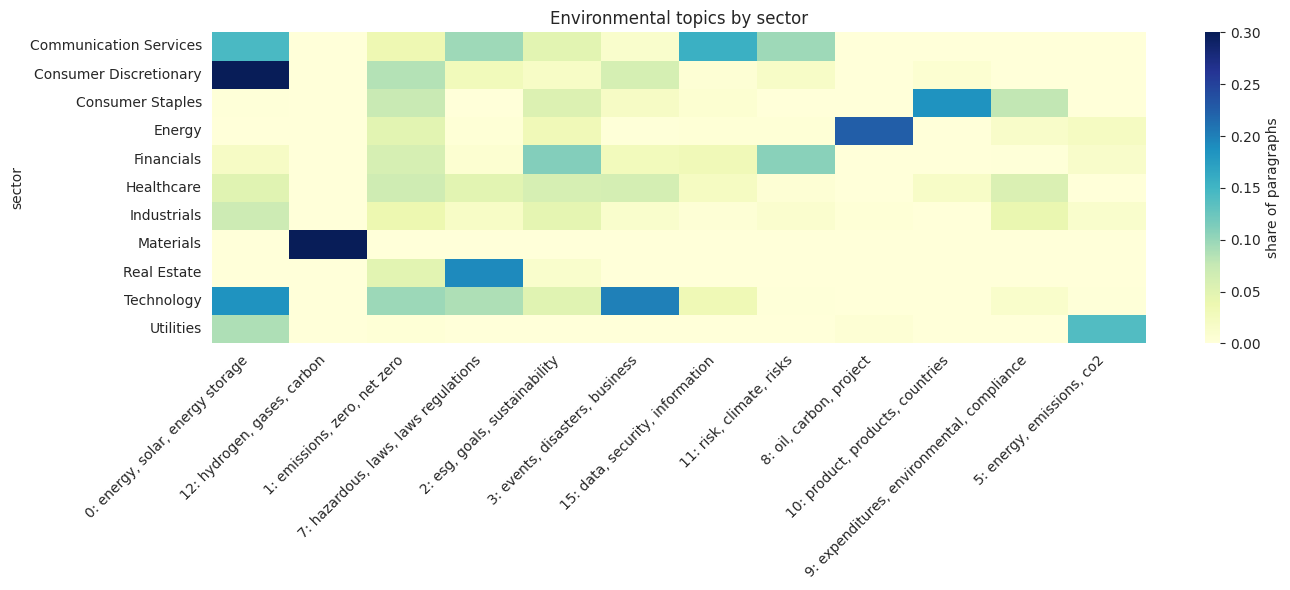

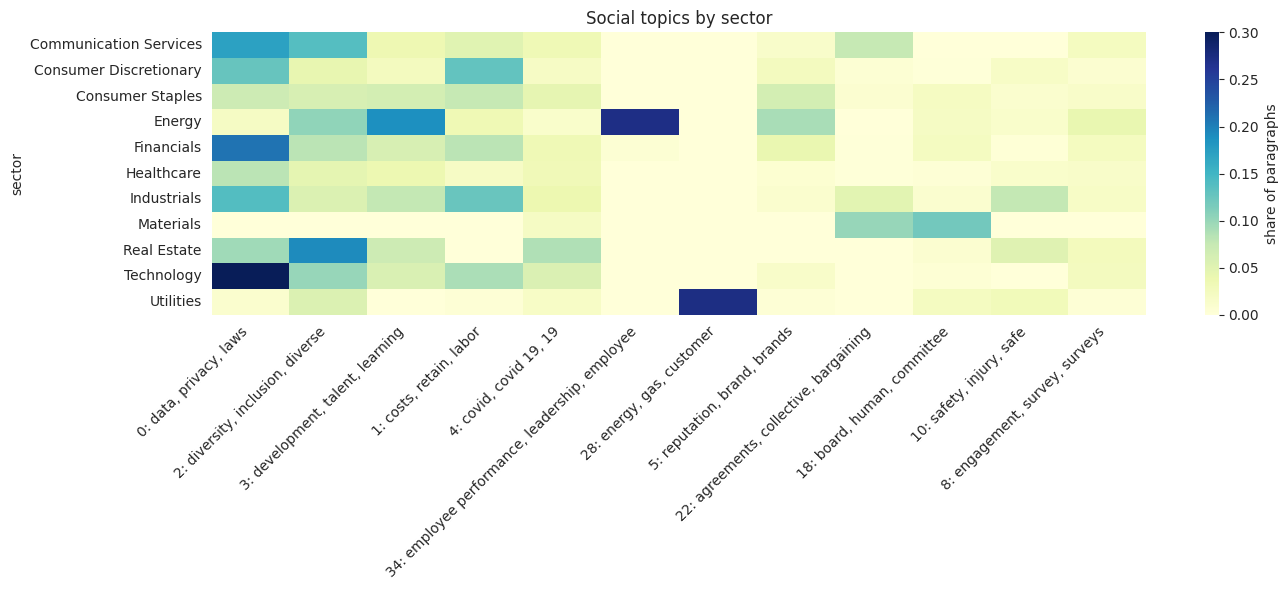

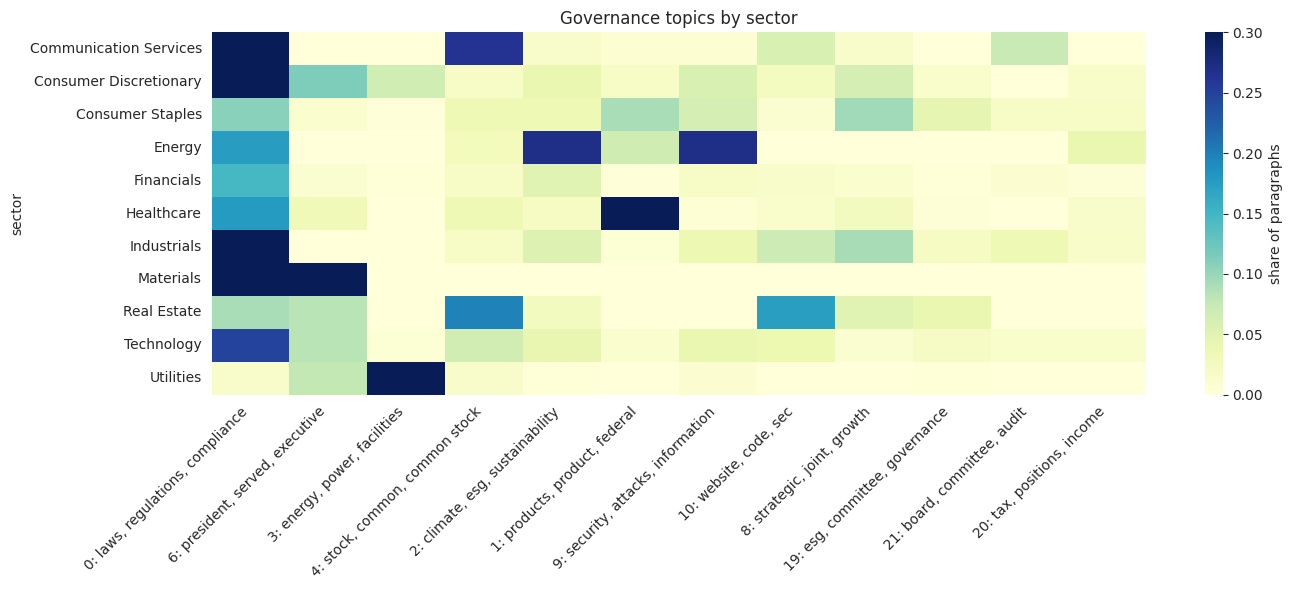

In [134]:
import seaborn as sns, matplotlib.pyplot as plt

def topic_heatmap(pillar, n_topics=12, vmax=0.3, title=None):
    tm, sub = pillar_models[pillar]
    prev = pd.crosstab(sub["sector"], sub["bt_topic"], normalize="index").drop(columns=-1)
    top = prev.sum().sort_values(ascending=False).head(n_topics).index
    labels = {t: f"{t}: " + ", ".join(w for w, _ in tm.get_topic(t)[:3]) for t in top}
    heat = prev[top].rename(columns=labels)
    plt.figure(figsize=(14, 6))
    sns.heatmap(heat, cmap="YlGnBu", vmax=vmax, cbar_kws={"label": "share of paragraphs"})
    plt.xticks(rotation=45, ha="right"); plt.xlabel("")
    plt.title(title or f"{pillar} topics by sector"); plt.tight_layout(); plt.show()

topic_heatmap("E", title="Environmental topics by sector")
topic_heatmap("S", title="Social topics by sector")
topic_heatmap("G", title="Governance topics by sector")

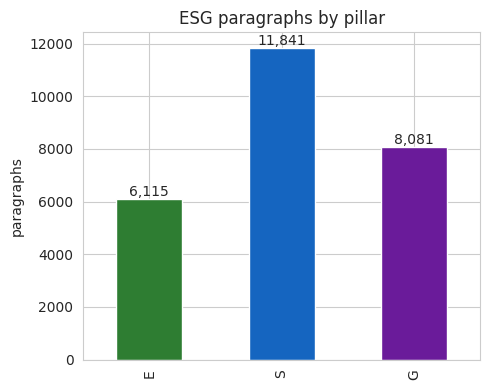

In [136]:
import matplotlib.pyplot as plt
counts = esg["label"].value_counts().reindex(["E", "S", "G"])
ax = counts.plot(kind="bar", color=["#2e7d32", "#1565c0", "#6a1b9a"], figsize=(5, 4))
ax.set_title("ESG paragraphs by pillar"); ax.set_xlabel(""); ax.set_ylabel("paragraphs")
for i, v in enumerate(counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

In [138]:
for pillar in ["E", "S", "G"]:
    tm, sub = pillar_models[pillar]
    valid = sub[sub["year"].str.fullmatch(r"\d{4}", na=False)].copy()
    years = valid["year"].astype(int).tolist()
    tot = tm.topics_over_time(valid["text"].tolist(), years)
    fig = tm.visualize_topics_over_time(tot, top_n_topics=8)
    fig.write_html(f"{pillar}_topics_over_time.html")
    print(f"saved {pillar}_topics_over_time.html")

saved E_topics_over_time.html
saved S_topics_over_time.html
saved G_topics_over_time.html


In [ ]:
esg_report = pd.read_cs